(1493, 13)
   task_id  rep    n  p  p_eff  corr       auc  ci_width  ci_lower  ci_upper  \
0        1    1  100  5    5.0   0.0  0.891114  0.157812  0.814621  0.972433   
1        5    5  100  5    5.0   0.0  0.815179  0.196987  0.728627  0.925614   
2        2    2  100  5    5.0   0.0  0.887054  0.175781  0.776730  0.952511   
3        8    8  100  5    5.0   0.0  0.837277  0.146875  0.757812  0.904687   
4        7    7  100  5    5.0   0.0  0.781667  0.242667  0.615444  0.858111   

   selected_mtry  selected_ntree  class_balance  
0              5             100           0.55  
1              1             400           0.46  
2              3             400           0.46  
3              1             100           0.53  
4              5             600           0.50  


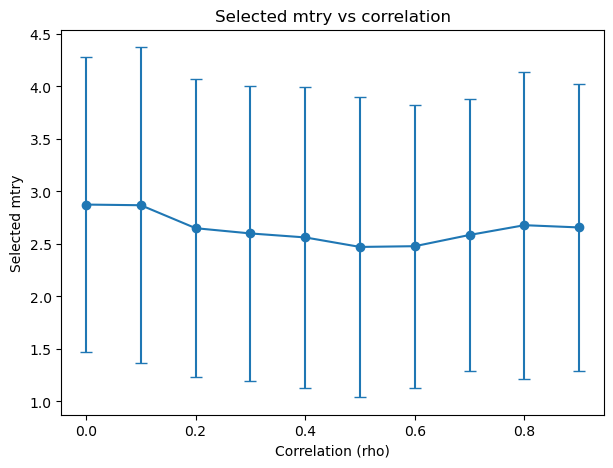

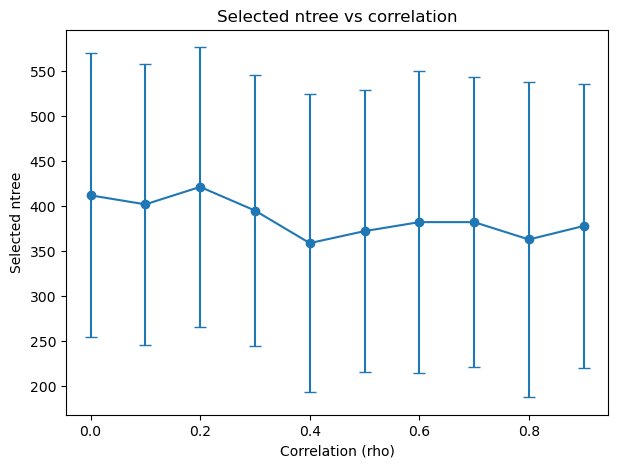

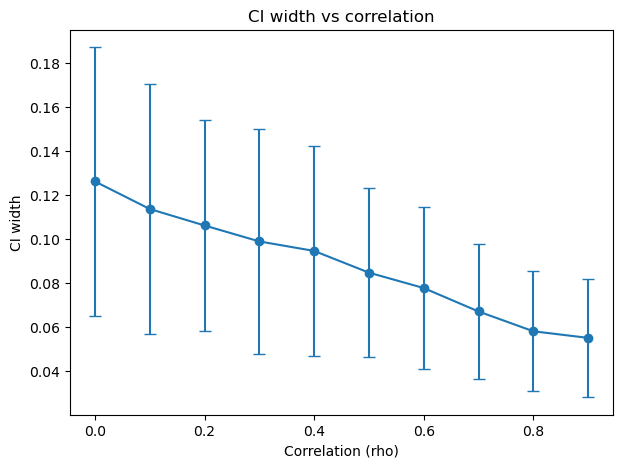

   corr   mtry_sd    ntree_sd   ci_mean  n_obs
0   0.0  1.404172  157.564752  0.126099    160
1   0.1  1.505219  156.000272  0.113596    160
2   0.2  1.419540  155.157660  0.106123    160
3   0.3  1.406186  150.387341  0.098884    160
4   0.4  1.431920  165.644440  0.094572    153
5   0.5  1.431621  156.888751  0.084725    140
6   0.6  1.348956  167.618897  0.077733    140
7   0.7  1.297400  161.052231  0.067105    140
8   0.8  1.460599  175.205063  0.058121    140
9   0.9  1.366461  157.346640  0.055123    140


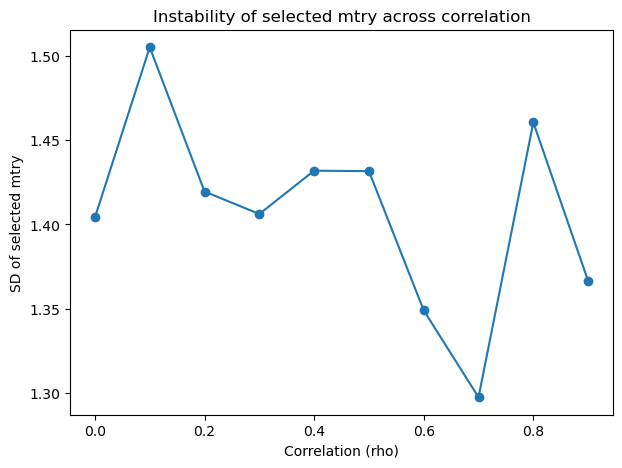

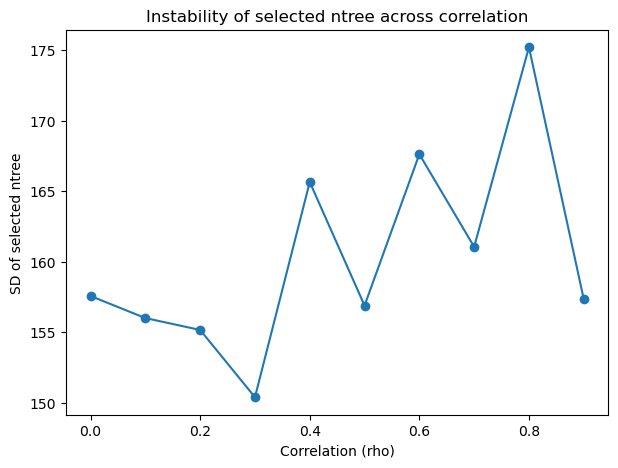

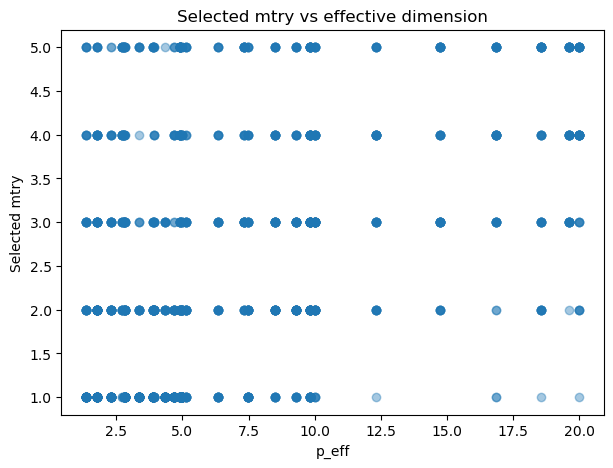

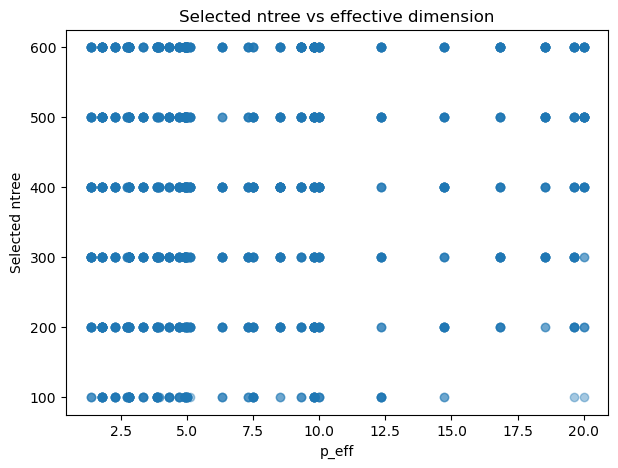

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
# load partial results
df = pd.read_csv("selected_results_ar1.csv")

print(df.shape)
print(df.head())

# make sure corr is sorted numerically
df = df.sort_values(["corr", "n", "p", "rep","p_eff"])

# -----------------------------
# 1) mean selected hyperparams by correlation
# -----------------------------
mtry_summary = df.groupby("corr")["selected_mtry"].agg(["mean", "std", "count"]).reset_index()
ntree_summary = df.groupby("corr")["selected_ntree"].agg(["mean", "std", "count"]).reset_index()
ci_summary = df.groupby("corr")["ci_width"].agg(["mean", "std", "count"]).reset_index()

plt.figure(figsize=(7,5))
plt.errorbar(
    mtry_summary["corr"],
    mtry_summary["mean"],
    yerr=mtry_summary["std"],
    marker="o",
    capsize=4
)
plt.xlabel("Correlation (rho)")
plt.ylabel("Selected mtry")
plt.title("Selected mtry vs correlation")
plt.show()

plt.figure(figsize=(7,5))
plt.errorbar(
    ntree_summary["corr"],
    ntree_summary["mean"],
    yerr=ntree_summary["std"],
    marker="o",
    capsize=4
)
plt.xlabel("Correlation (rho)")
plt.ylabel("Selected ntree")
plt.title("Selected ntree vs correlation")
plt.show()

plt.figure(figsize=(7,5))
plt.errorbar(
    ci_summary["corr"],
    ci_summary["mean"],
    yerr=ci_summary["std"],
    marker="o",
    capsize=4
)
plt.xlabel("Correlation (rho)")
plt.ylabel("CI width")
plt.title("CI width vs correlation")
plt.show()

# -----------------------------
# 2) spread / instability by correlation
# -----------------------------
spread = df.groupby("corr").agg(
    mtry_sd=("selected_mtry", "std"),
    ntree_sd=("selected_ntree", "std"),
    ci_mean=("ci_width", "mean"),
    n_obs=("task_id", "count")
).reset_index()

print(spread)

plt.figure(figsize=(7,5))
plt.plot(spread["corr"], spread["mtry_sd"], marker="o")
plt.xlabel("Correlation (rho)")
plt.ylabel("SD of selected mtry")
plt.title("Instability of selected mtry across correlation")
plt.show()

plt.figure(figsize=(7,5))
plt.plot(spread["corr"], spread["ntree_sd"], marker="o")
plt.xlabel("Correlation (rho)")
plt.ylabel("SD of selected ntree")
plt.title("Instability of selected ntree across correlation")
plt.show()

# -----------------------------
# 3) optional: look at effect of p_eff
# -----------------------------
plt.figure(figsize=(7,5))
plt.scatter(df["p_eff"], df["selected_mtry"], alpha=0.4)
plt.xlabel("p_eff")
plt.ylabel("Selected mtry")
plt.title("Selected mtry vs effective dimension")
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(df["p_eff"], df["selected_ntree"], alpha=0.4)
plt.xlabel("p_eff")
plt.ylabel("Selected ntree")
plt.title("Selected ntree vs effective dimension")
plt.show()

In [2]:
import numpy as np
df["mtry_p_eff"]=df["selected_mtry"]/df["p_eff"]
df["ratio_np"] = df["n"] / df["p_eff"]
df["log_ratio"]=np.log(df["ratio_np"])
model_loglog = smf.ols(
    "mtry_p_eff ~ corr*log_ratio",
    data=df
).fit()

print(model_loglog.summary())

                            OLS Regression Results                            
Dep. Variable:             mtry_p_eff   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     340.3
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          2.94e-168
Time:                        04:12:38   Log-Likelihood:                -749.66
No. Observations:                1493   AIC:                             1507.
Df Residuals:                    1489   BIC:                             1529.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.3238      0.068      4.

In [3]:
df["mtry_p_eff"]=df["selected_mtry"]/df["p_eff"]
from scipy.stats import spearmanr
for c in df["corr"].unique():
    subset = df[df["corr"] == c]
    rho, p = spearmanr(subset["log_ratio"], subset["mtry_p_eff"])
    print(c, rho, p)

0.0 0.212251550767211 0.007049117258553286
0.1 0.05102289396347561 0.5216842060318423
0.2 0.07870179452324959 0.3225469125217467
0.3 0.0025357100650077137 0.9746131725872664
0.4 0.1994623304797283 0.013440807911633998
0.5 0.14512283684278088 0.08711974483507985
0.6 0.3439622506040404 3.168340923018964e-05
0.7 0.2756000471188594 0.0009815053006552354
0.8 0.07212375606383252 0.39708853739113337
0.9 0.022187570958008333 0.7947054630601115


In [8]:
unique_values = list(set(df["n"]))
unique_values

[100, 500, 300]